#Actividad 3.8: Análisis Socioformador

##Generación del Frame

In [ ]:
%pip install statsmodels

In [ ]:
#Instalamos la libreria STREAMLIT
%pip install streamlit

In [ ]:
#Instalamos la librería de PLOTLY
%pip install plotly

In [ ]:
#Instalamos la libreria para analisis de variables categoricas
%pip install funpymodeling

In [ ]:
#Instalamos el tunnel local (node.js)
!npm install localtunnel

In [ ]:
#Importamos librerias
import streamlit as st
import plotly.express as px
import pandas as pd
import numpy as np
from funpymodeling.exploratory import freq_tbl
import matplotlib.pyplot as plt
import scipy.special as special
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

In [ ]:
#Cargar un archivo
from google.colab import files
files.upload()

In [ ]:
#Ajustar el maximo de columnas
pd.options.display.max_columns = None

#Ajustar el maximo de filas
pd.options.display.max_rows = None

In [ ]:
#Crear DataFrame
data = pd.read_csv('P07_v07_atribMOVPREFAE_etiq.csv',encoding='utf-8')
data.head()

,Veloc,Acele,Des_x,Des_y,Des_z,Presn,VelPr,AcePr,F5EEX,F6EES,F8EIX,F7EIS,F9EEX,F10ES,F11EX,F12ES,F13EV,F14EV,F17MS,F18MX,F15MS,F16MX,F19MH,F20MH,F1EBX,F2EBS,F4EBX,F3EBS,01_C,02_A,03_D,04_M
0,0.336887,0.157121,0.300689,0.424425,0.071930,0.857143,0.333333,0.4,0.346705,0.472610,0.422882,0.357413,0.303710,0.418008,0.318239,0.322014,0.685798,0.755874,0.151228,0.468333,0.275408,0.459430,0.400018,0.315977,0.167550,0.694361,0.626980,0.441086,-1,-1,-1,-1
1,0.348517,0.106910,0.331456,0.406917,0.087321,0.857143,0.333333,0.4,0.321484,0.513549,0.427267,0.362119,0.291442,0.447879,0.316963,0.346334,0.677932,0.764096,0.148976,0.478529,0.283015,0.469285,0.409222,0.310309,0.180527,0.682648,0.622604,0.412756,-1,-1,-1,-1
2,0.305108,0.076626,0.240929,0.390983,0.093437,0.857143,0.333333,0.2,0.289997,0.491946,0.396118,0.333875,0.275743,0.439534,0.276041,0.317150,0.675187,0.769436,0.132865,0.475486,0.265487,0.491818,0.400053,0.311215,0.177046,0.664700,0.620731,0.392168,-1,-1,-1,-1
3,0.283169,0.077250,0.258755,0.333111,0.099255,0.857143,0.444444,0.2,0.297746,0.512638,0.408328,0.347601,0.285556,0.452627,0.292378,0.338343,0.682613,0.782017,0.122577,0.456306,0.262795,0.475981,0.384387,0.307770,0.195125,0.644808,0.611000,0.387480,-1,-1,-1,-1
4,0.219282,0.074000,0.183373,0.259734,0.109342,0.857143,0.444444,0.4,0.293674,0.529815,0.431696,0.375093,0.291625,0.465717,0.313134,0.357148,0.672006,0.765580,0.128232,0.457811,0.275423,0.481840,0.396209,0.297740,0.228031,0.615692,0.595794,0.379562,-1,-1,-1,-1


##Análisis del Frame

In [ ]:
data.shape

(9193, 32)

In [ ]:
data.isnull().sum()

,0
Veloc,0
Acele,0
Des_x,0
Des_y,0
Des_z,0
Presn,0
VelPr,0
AcePr,0
F5EEX,0
F6EES,0


##Limpieza de Valores Atípicos

<Figure size 1500x800 with 0 Axes>

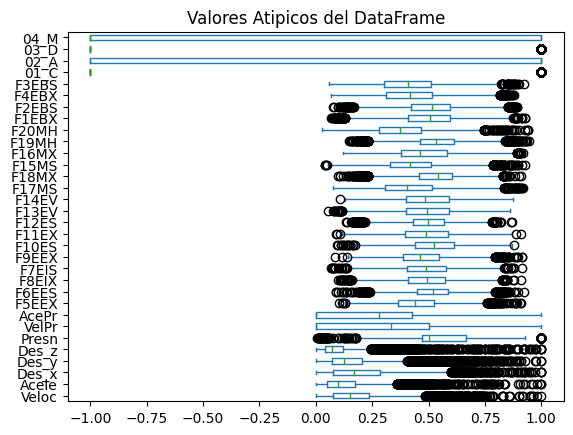

In [ ]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize = (15,8))
data.plot(kind='box', vert=False)
plt.title('Valores Atipicos del DataFrame')
plt.show() #Dibujamos el diagrama

In [ ]:
#Metodo aplicando desviación estandar. Encuentro los valores extremos
data_val = data.drop(['01_C','02_A','03_D','04_M'], axis=1)
y = data_val
Limite_Superior = y.mean() + 3*y.std()
Limite_Inferior = y.mean() - 3*y.std()
print('Limite superior permitido:\n',Limite_Superior)
print()
print('Limite inferior permitido:\n',Limite_Inferior)

Limite superior permitido:
 Veloc    0.558257
Acele    0.454241
Des_x    0.667426
Des_y    0.559102
Des_z    0.430980
Presn    1.045409
VelPr    1.031848
AcePr    1.015865
F5EEX    0.791702
F6EES    0.832360
F8EIX    0.851166
F7EIS    0.859697
F9EEX    0.817669
F10ES    0.887535
F11EX    0.880178
F12ES    0.815068
F13EV    0.894645
F14EV    0.880756
F17MS    0.852600
F18MX    0.868072
F15MS    0.849304
F16MX    0.922675
F19MH    0.916597
F20MH    0.782534
F1EBX    0.915127
F2EBS    0.891697
F4EBX    0.837885
F3EBS    0.837730
dtype: float64

Limite inferior permitido:
 Veloc   -0.208876
Acele   -0.198829
Des_x   -0.262614
Des_y   -0.234220
Des_z   -0.226404
Presn    0.051889
VelPr   -0.406185
AcePr   -0.440759
F5EEX    0.107095
F6EES    0.201050
F8EIX    0.130729
F7EIS    0.123310
F9EEX    0.123138
F10ES    0.162363
F11EX    0.102939
F12ES    0.184446
F13EV    0.094466
F14EV    0.111265
F17MS   -0.021395
F18MX    0.189916
F15MS   -0.017422
F16MX    0.044224
F19MH    0.160286
F20MH   -0

In [ ]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data_clean = data_val[(y <= Limite_Superior) & (y >= Limite_Inferior)]
data_clean.head()

,Veloc,Acele,Des_x,Des_y,Des_z,Presn,VelPr,AcePr,F5EEX,F6EES,F8EIX,F7EIS,F9EEX,F10ES,F11EX,F12ES,F13EV,F14EV,F17MS,F18MX,F15MS,F16MX,F19MH,F20MH,F1EBX,F2EBS,F4EBX,F3EBS
0,0.336887,0.157121,0.300689,0.424425,0.071930,0.857143,0.333333,0.4,0.346705,0.472610,0.422882,0.357413,0.303710,0.418008,0.318239,0.322014,0.685798,0.755874,0.151228,0.468333,0.275408,0.459430,0.400018,0.315977,0.167550,0.694361,0.626980,0.441086
1,0.348517,0.106910,0.331456,0.406917,0.087321,0.857143,0.333333,0.4,0.321484,0.513549,0.427267,0.362119,0.291442,0.447879,0.316963,0.346334,0.677932,0.764096,0.148976,0.478529,0.283015,0.469285,0.409222,0.310309,0.180527,0.682648,0.622604,0.412756
2,0.305108,0.076626,0.240929,0.390983,0.093437,0.857143,0.333333,0.2,0.289997,0.491946,0.396118,0.333875,0.275743,0.439534,0.276041,0.317150,0.675187,0.769436,0.132865,0.475486,0.265487,0.491818,0.400053,0.311215,0.177046,0.664700,0.620731,0.392168
3,0.283169,0.077250,0.258755,0.333111,0.099255,0.857143,0.444444,0.2,0.297746,0.512638,0.408328,0.347601,0.285556,0.452627,0.292378,0.338343,0.682613,0.782017,0.122577,0.456306,0.262795,0.475981,0.384387,0.307770,0.195125,0.644808,0.611000,0.387480
4,0.219282,0.074000,0.183373,0.259734,0.109342,0.857143,0.444444,0.4,0.293674,0.529815,0.431696,0.375093,0.291625,0.465717,0.313134,0.357148,0.672006,0.765580,0.128232,0.457811,0.275423,0.481840,0.396209,0.297740,0.228031,0.615692,0.595794,0.379562


In [ ]:
data_clean['01_C'] = data['01_C']
data_clean['02_A'] = data['02_A']
data_clean['03_D'] = data['03_D']
data_clean['04_M'] = data['04_M']

##Limpieza de Valores Nulos

In [ ]:
#Corroboramos valores nulos del dataframe
valores_nulos = data_clean.isnull().sum()
valores_nulos

,0
Veloc,160
Acele,157
Des_x,99
Des_y,197
Des_z,147
Presn,35
VelPr,0
AcePr,0
F5EEX,29
F6EES,42


In [ ]:
data_cleansed = data_clean.copy()

In [ ]:
#Sustituir valores nulos con promedio o media
data_cleansed['Veloc'] = data_cleansed['Veloc'].fillna(round(data_clean['Veloc'].mean(),6))
data_cleansed['Acele'] = data_cleansed['Acele'].fillna(round(data_clean['Acele'].mean(),6))
data_cleansed['Des_x'] = data_cleansed['Des_x'].fillna(round(data_clean['Des_x'].mean(),6))
data_cleansed['Des_y'] = data_cleansed['Des_y'].fillna(round(data_clean['Des_y'].mean(),6))
data_cleansed['Des_z'] = data_cleansed['Des_z'].fillna(round(data_clean['Des_z'].mean(),6))
data_cleansed['Presn'] = data_cleansed['Presn'].fillna(round(data_clean['Presn'].mean(),6))

In [ ]:
#Sustituiir valores nulos por valores no nulos hacia adelante 'forward fill' ('ffill')
data_cleansed['F5EEX']  = data_cleansed['F5EEX'].fillna(method='ffill')
data_cleansed['F6EES']  = data_cleansed['F6EES'].fillna(method='ffill')
data_cleansed['F8EIX']  = data_cleansed['F8EIX'].fillna(method='ffill')
data_cleansed['F7EIS']  = data_cleansed['F7EIS'].fillna(method='ffill')
data_cleansed['F9EEX']  = data_cleansed['F9EEX'].fillna(method='ffill')
data_cleansed['F10ES']  = data_cleansed['F10ES'].fillna(method='ffill')
data_cleansed['F11EX']  = data_cleansed['F11EX'].fillna(method='ffill')
data_cleansed['F12ES']  = data_cleansed['F12ES'].fillna(method='ffill')
data_cleansed['F13EV']  = data_cleansed['F13EV'].fillna(method='ffill')
data_cleansed['F14EV']  = data_cleansed['F14EV'].fillna(method='ffill')
data_cleansed['F17MS']  = data_cleansed['F17MS'].fillna(method='ffill')
data_cleansed['F18MX']  = data_cleansed['F18MX'].fillna(method='ffill')
data_cleansed['F15MS']  = data_cleansed['F15MS'].fillna(method='ffill')
data_cleansed['F19MH']  = data_cleansed['F19MH'].fillna(method='ffill')
data_cleansed['F20MH']  = data_cleansed['F20MH'].fillna(method='ffill')
data_cleansed['F1EBX']  = data_cleansed['F1EBX'].fillna(method='ffill')
data_cleansed['F2EBS']  = data_cleansed['F2EBS'].fillna(method='ffill')
data_cleansed['F4EBX']  = data_cleansed['F4EBX'].fillna(method='ffill')
data_cleansed['F3EBS']  = data_cleansed['F3EBS'].fillna(method='ffill')

<ipython-input-18-fa16946321c2>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_cleansed['F5EEX']  = data_cleansed['F5EEX'].fillna(method='ffill')
<ipython-input-18-fa16946321c2>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_cleansed['F6EES']  = data_cleansed['F6EES'].fillna(method='ffill')
<ipython-input-18-fa16946321c2>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_cleansed['F8EIX']  = data_cleansed['F8EIX'].fillna(method='ffill')
<ipython-input-18-fa16946321c2>:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_cleansed['F7EIS']  = data_cleansed['F7EIS'].fillna(method='ffill')
<ipython-input-18-fa16946321c2>:

In [ ]:
#Corroboramos valores nulos del dataframe
valores_nulos = data_cleansed.isnull().sum()
valores_nulos

,0
Veloc,0
Acele,0
Des_x,0
Des_y,0
Des_z,0
Presn,0
VelPr,0
AcePr,0
F5EEX,0
F6EES,0


In [ ]:
#Convertir DataFrame a csv
data_cleansed.to_csv('P07_v07_atribMOVPREFAE_etiq_CLEAN.csv')

In [ ]:
from google.colab import files
files.download('P07_v07_atribMOVPREFAE_etiq_CLEAN.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##División en SubFrames

In [ ]:
data_cleansed.shape

(9193, 32)

In [ ]:
data_cansancio = data_cleansed[data_cleansed['01_C'] == 1]
data_cansancio.shape

(163, 32)

In [ ]:
data_ansiedad = data_cleansed[data_cleansed['02_A'] == 1]
data_ansiedad.shape

(5330, 32)

In [ ]:
data_dolor = data_cleansed[data_cleansed['03_D'] == 1]
data_dolor.shape

(707, 32)

In [ ]:
data_meditacion = data_cleansed[data_cleansed['04_M'] == 1]
data_meditacion.shape

(3464, 32)